# NYC airbnb analysis

### Modules

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import geopandas as gpd
import requests
from bs4 import BeautifulSoup
import csv

### Basic configuration

In [2]:
pd.set_option('precision', 2)
#pd.set_option('display.max_rows', 100)
pd.options.display.max_columns = 20
%matplotlib inline

# Location where the plots will be saved
project_dir = "."
img_path = os.path.join(project_dir, "Drawings")

# Function for saving the plots
def save_plot(plot_id, extension="jpg", resolution=350):
    os.makedirs(img_path, exist_ok=True)
    plot_path = os.path.join(img_path, plot_id + "." + extension)
    plt.savefig(plot_path, format=extension, dpi=resolution)

### Main dataset load

In [3]:
data_path = os.path.join(project_dir, 'AB_NYC_2019.csv')
nyc_data = pd.read_csv(data_path)
nyc_data.head(3)

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.65,-73.97,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75,-73.98,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.81,-73.94,Private room,150,3,0,NaN,NaN,1,365


### Data exploration

##### Task 1: In which region are the highest listing prices?

To answer (visualize) above question we need to:
1. Load background map;
2. Extract necessary information for each borough from Wikipedia;
3. Save scrapped data to CSV file and load to dataframe;
4. Create dataframe with average prices for each neighbourhood;
5. Join scrapped data with average prices;
6. Create dataframe with community board average prices;
7. Join community board average prices with map dataset;
8. Visualize data.

,boro_cd,shape_area,shape_leng,geometry
0,311.0,1.03e+08,51549.56,"POLYGON ((-8234636.062 4926994.095, -8234591.0..."
1,313.0,8.82e+07,65821.88,"POLYGON ((-8235830.207 4925096.442, -8235755.0..."
2,312.0,9.95e+07,52245.83,"POLYGON ((-8234458.171 4932757.168, -8234437.4..."
3,104.0,4.93e+07,67623.95,"POLYGON ((-8236967.382 4951032.051, -8236940.6..."
4,304.0,5.67e+07,37008.10,"POLYGON ((-8226116.994 4937739.130, -8226123.6..."


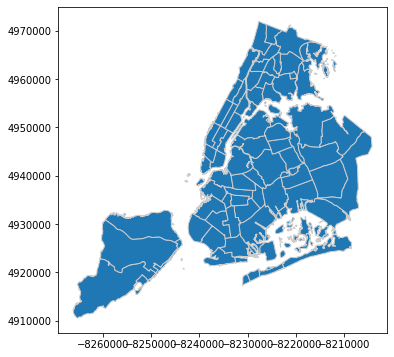

In [4]:
# 1. Load background map
map_path = os.path.join(project_dir, "Community_Districts/geo_export_5358b392-fc86-4a60-a5de-cf65c437d08f.shp")
map_data = gpd.read_file(map_path)

# Convert data to Web Mercator (Mercator projection)
crs = {'init':'epsg:3395'}
map_data = map_data.to_crs(crs=crs)

map_data.plot(figsize=(6,6), edgecolor='0.8')
save_plot("nyc_clean_map")
map_data.head()

'boro_cd' column contains the numbers for each borough in NYC (e.g. first digit in value 101 (1) refers to the borough name (Manhattan) and the rest (01) is the community board number. Each community board contains specific neighbourhoods (Melrose, Mott Haven, Port Morris)).

In [5]:
# 2. Extract necessary information for each borough from Wikipedia
# Connect with Wikipedia
res = requests.get("https://en.wikipedia.org/wiki/Neighborhoods_in_New_York_City")
res.raise_for_status()

# Scrape data
soup = BeautifulSoup(res.text, 'html.parser')
element = soup.select('.mw-parser-output .wikitable a')

In [6]:
# 3. Save scrapped data to CSV file and load to dataframe
csv_path = os.path.join(project_dir, 'boro_nyc.csv')
csv_output = open(csv_path, 'w+', newline='')
csv_writer = csv.writer(csv_output)
csv_writer.writerow(['boro_name', 'boro_cd', 'neighbourhood'])

for i in range(len(element)):    # tuple to format scrapped text
    text = element[i].getText().replace(u'\xa0', u' ')
    if 'CB' in text:
        boro_name = text[:text.find('C')].strip()
        boro_cd = text[-2:].strip()
        if boro_name == 'Manhattan':
            boro_cd = '10' + boro_cd if len(boro_cd)==1 else '1' + boro_cd
        elif boro_name == 'Bronx':
            boro_cd = '20' + boro_cd if len(boro_cd)==1 else '2' + boro_cd
        elif boro_name == 'Brooklyn':
            boro_cd = '30' + boro_cd if len(boro_cd)==1 else '3' + boro_cd
        elif boro_name == 'Queens':
            boro_cd = '40' + boro_cd if len(boro_cd)==1 else '4' + boro_cd
        else:
            boro_cd = '50' + boro_cd if len(boro_cd)==1 else '5' + boro_cd
    else:
        csv_writer.writerow([boro_name, boro_cd, text])

csv_output.close()

# Load to dataframe
cb_data = pd.read_csv(csv_path)

In [7]:
# 4. Create dataframe with average prices for each neighbourhood
avg_prices = pd.DataFrame({
    "neighbourhood": np.sort(nyc_data['neighbourhood'].unique()).tolist(),
    "avg_price": nyc_data.groupby(['neighbourhood']).mean()['price'].to_list()
})

In [8]:
# 5. Join scrapped data with average prices
merged_cb_avg = pd.merge(cb_data, avg_prices, on='neighbourhood', how='inner')

In [9]:
# 6. Create dataframe with community board average prices
boro_cd_avg = pd.DataFrame({
    "boro_cd": np.sort(merged_cb_avg['boro_cd'].unique()).tolist(),
    "avg_price": merged_cb_avg.groupby(['boro_cd']).mean()['avg_price'].to_list()
})

In [10]:
# 7. Join community board average prices with map dataset
prices_data = pd.merge(map_data, boro_cd_avg, on='boro_cd', how='left')

# Data clean-up
prices_data['avg_price'].fillna(0, inplace=True)

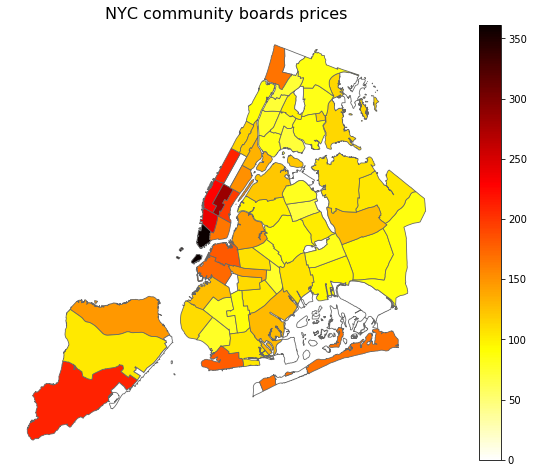

In [11]:
# 8. Visualization
var = 'avg_price'
vmin = prices_data['avg_price'].min()
vmax = prices_data['avg_price'].max()

fig, ax = plt.subplots(1, figsize=(12,8))
prices_data.plot(column=var, cmap=plt.get_cmap("hot_r"), linewidth=0.8, ax=ax, edgecolor='0.4', legend=True)
plt.title("NYC community boards prices", size=16)
plt.axis('off')

save_plot("cb_prices")

plt.show()

##### Task 2: What is the range of prices in each neighbourhood group?

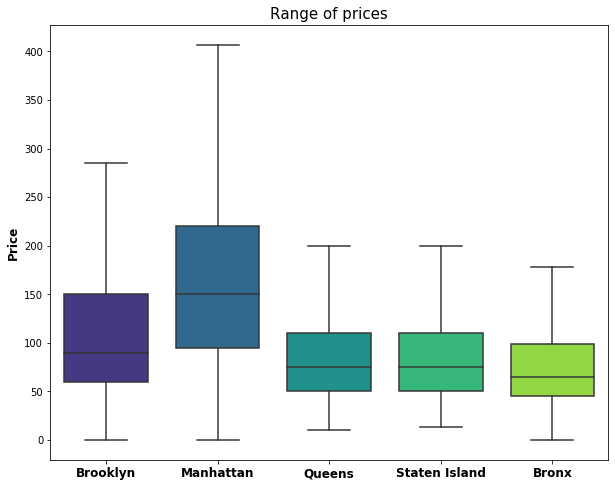

In [12]:
groups = (nyc_data['neighbourhood_group'].unique()).tolist()

plt.figure(figsize=(10,8))
bp = sns.boxplot(data=nyc_data, x='neighbourhood_group', y='price', palette='viridis', saturation=1, 
                 showfliers=False, width=0.75)
bp.set_xlabel('')
bp.set_ylabel('Price', size=12, weight='bold')
bp.set_xticklabels(groups, size=12, weight='bold')
bp.set_title('Range of prices', size=15)

save_plot("price_ranges")

plt.show()

##### Task 3: What is the number of different types of houses in each neighbour group?

In [13]:
room_count = pd.DataFrame({
    "count": nyc_data.groupby(['neighbourhood_group', 'room_type']).size()
}).reset_index()

In [14]:
labels = (room_count['room_type'].unique()).tolist()
groups = (room_count['neighbourhood_group'].unique()).tolist()

brx_vals = room_count['count'][room_count['neighbourhood_group']==groups[0]]
brn_vals = room_count['count'][room_count['neighbourhood_group']==groups[1]]
mht_vals = room_count['count'][room_count['neighbourhood_group']==groups[2]]
qns_vals = room_count['count'][room_count['neighbourhood_group']==groups[3]]
stl_vals = room_count['count'][room_count['neighbourhood_group']==groups[4]]

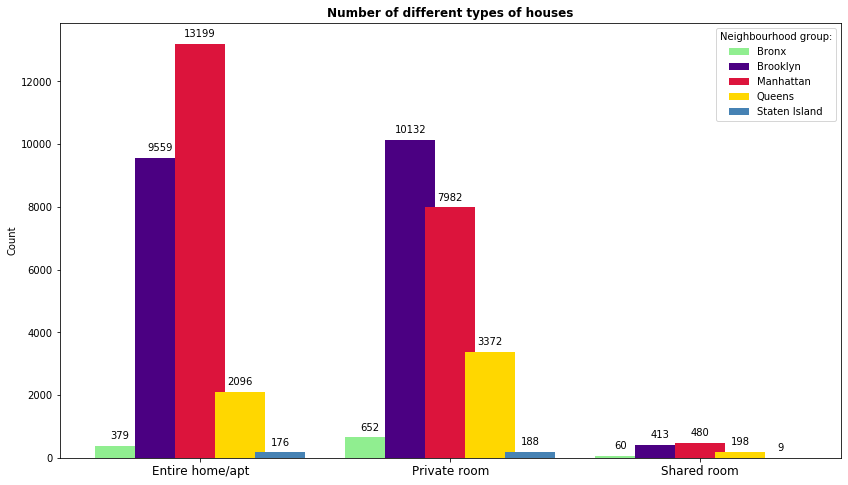

In [15]:
x = np.arange(len(labels))
width = 0.8

fig, ax = plt.subplots(figsize=(14,8))
rects1 = ax.bar(x - width/2.5, brx_vals, width=0.2, label=groups[0], color='lightgreen')
rects2 = ax.bar(x - width/5, brn_vals, width=0.2, label=groups[1], color='indigo')
rects3 = ax.bar(x, mht_vals, width=0.2, label=groups[2], color='crimson')
rects4 = ax.bar(x + width/5, qns_vals, width=0.2, label=groups[3], color='gold')
rects5 = ax.bar(x + width/2.5, stl_vals, width=0.2, label=groups[4], color='steelblue')

ax.set_ylabel('Count')
ax.set_title('Number of different types of houses', weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, size=12)
ax.legend(title='Neighbourhood group:')

def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),  # 5 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
autolabel(rects4)
autolabel(rects5)

save_plot("houses_types")
        
plt.show()

##### Task 4: What is the distribution of house types in NYC area?

In [16]:
# Load background NYC map available in geopandas datasets
nyc_map = gpd.read_file(gpd.datasets.get_path('nybb'))

# Convert data to Web Mercator (Mercator projection)
nyc_map = nyc_map.to_crs(epsg=4326)
crs = {'init': 'epsg:4326'}

# Creating a GeoDataFrame from a DataFrame with coordinates
nyc_map_data = gpd.GeoDataFrame(nyc_data, crs=crs, 
                                geometry=gpd.points_from_xy(nyc_data.longitude, nyc_data.latitude))

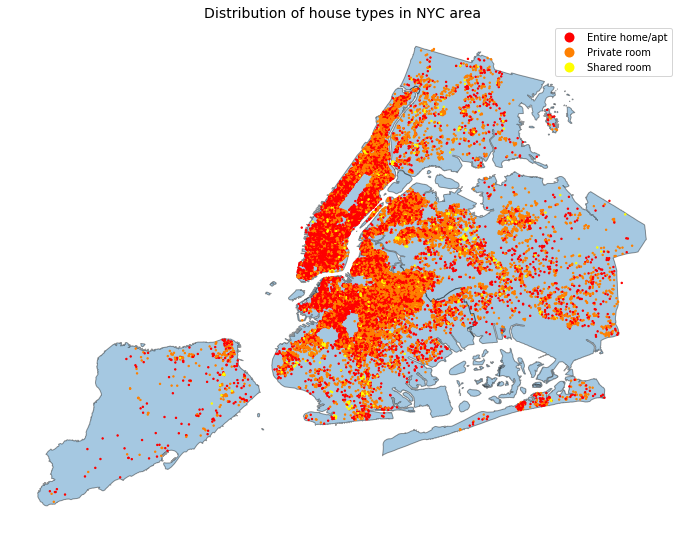

In [17]:
var = 'room_type'

# Specify color for each house type
color_dict = {'Entire home/apt': 'red', 'Private room': 'green', 'Shared room': 'blue'}

fig, ax = plt.subplots(figsize=(12,12))
nyc_map.plot(ax=ax, alpha=0.4, edgecolor='k')
nyc_map_data.plot(column=var, ax=ax, cmap=plt.get_cmap("autumn") , marker='o', markersize=2, legend=True)
plt.title("Distribution of house types in NYC area", size=14)
plt.axis('off')

save_plot("houses_distribution")

plt.show()